# 🚢 TITANIC SURVIVAL PREDICTION
**Objective:** Use Machine Learning to predict which passengers will survive based on information such as age, gender, ticket class, etc.

**Steps to implement:**
1. SETUP & OVERVIEW (Initialization & Summary)
2. DATA CLEANING (Data cleaning)
3. FEATURE ENGINEERING (Feature engineering technique)
4. EXPLORATORY ANALYSIS (EDA - Visualization)
5. MODEL EXPERIMENTS (Model training)
6. DEPLOYMENT (Deployment)

# **1. SETUP & OVERVIEW (Initialization & Summary)**

## Install Required Packages

In [1]:
# Install required packages
%pip install pandas numpy matplotlib seaborn scikit-learn ipywidgets
print("✅ All packages installed successfully!")

Note: you may need to restart the kernel to use updated packages.
✅ All packages installed successfully!


## Import Libraries

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, f1_score
import os
import warnings
import scipy.stats as stats

# Display configuration
pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [3]:
# Load the Titanic dataset
# Make sure 'titanic_detailed_passengers_data.csv' is in the same directory as this notebook
file_path = 'titanic_detailed_passengers_data.csv'

try:
    df = pd.read_csv(file_path)
    print("✅ File loaded successfully!")
    print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
    print("\nFirst 5 rows:")
    display(df.head())
except FileNotFoundError:
    print("❌ ERROR: File not found!")
    print(f"Please make sure 'titanic_detailed_passengers_data.csv' is in: {os.getcwd()}")

✅ File loaded successfully!
Dataset shape: 601 rows, 17 columns

First 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,Title,IsMarried,SibSp,Parch,FamilySize,Fare,FareGroup,Cabin,Deck,Embarked,AgeGroup
0,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,Mrs,1,1,0,2,71.2833,Very High,C85,C,C,Adult
1,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,Mrs,1,1,0,2,53.1000,Very High,C123,C,S,Young Adult
2,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,Mr,0,0,0,1,51.8625,Very High,E46,E,S,Middle-aged
3,11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,Miss,0,1,1,3,16.7000,High,G6,G,S,Child
4,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,Miss,0,0,0,1,26.5500,High,C103,C,S,Middle-aged


## Introduction to the Dataset

**Explanation of the Titanic Dataset**

**Dataset Overview:** The detailed Titanic dataset contains comprehensive information about passengers on the Titanic, including both basic features and preprocessed characteristics.

**Data Structure:**

* **Rows:** 601
* **Columns:** 17

**Main Columns:**

* **`PassengerId`:** Unique identifier for each passenger.
* **`Survived`:** Target variable indicating whether the passenger survived (1) or not (0).
* **`Pclass`:** Ticket class (Class 1, 2, or 3).
* **`Name`:** Full name of the passenger.
* **`Sex`:** Gender of the passenger (male/female).
* **`Age`:** Age of the passenger (in years).
* **`Title`:** Title of the passenger (Mr, Mrs, Miss, Master, Dr, Rev, etc.).
* **`IsMarried`:** Marital status of the passenger (0 or 1).
* **`SibSp`:** Number of siblings/spouses traveling with the passenger on the Titanic.
* **`Parch`:** Number of parents/children traveling with the passenger on the Titanic.
* **`FamilySize`:** Total family size (including the passenger).
* **`Fare`:** Ticket price (charged for the entire family).
* **`FareGroup`:** Fare category classification (Low, High, Very High).
* **`Cabin`:** Room number where the passenger stayed.
* **`Deck`:** Ship deck extracted from the Cabin column.
* **`Embarked`:** Port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton).
* **`AgeGroup`:** Age group classification (Child, Teenager, Young Adult, Adult, Middle-aged, Senior).

**Purpose:** This dataset is ideal for advanced Exploratory Data Analysis (EDA) and Machine Learning tasks, including survival prediction, analyzing the impact of different features on survival, and discovering demographic patterns.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 601 entries, 0 to 600
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  601 non-null    int64  
 1   Survived     601 non-null    int64  
 2   Pclass       601 non-null    int64  
 3   Name         601 non-null    object 
 4   Sex          601 non-null    object 
 5   Age          601 non-null    float64
 6   Title        601 non-null    object 
 7   IsMarried    601 non-null    int64  
 8   SibSp        601 non-null    int64  
 9   Parch        601 non-null    int64  
 10  FamilySize   601 non-null    int64  
 11  Fare         601 non-null    float64
 12  FareGroup    601 non-null    object 
 13  Cabin        274 non-null    object 
 14  Deck         601 non-null    object 
 15  Embarked     601 non-null    object 
 16  AgeGroup     601 non-null    object 
dtypes: float64(2), int64(7), object(8)
memory usage: 79.9+ KB


# **2. DATA CLEANING (Data Cleaning)**

## Check for Duplicate Data

In [5]:
print(f"Duplicates: {df.duplicated().sum()}")

Duplicates: 0


## Check for Missing Data

In [6]:
print("Number of missing values (NaN) in each column:")
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0])

Number of missing values (NaN) in each column:
Cabin    327
dtype: int64


## Fill Missing Data

In [7]:
# Create a clean copy and handle missing data
df_clean = df.copy()

# No major missing values to handle in this dataset
# The data is already well-preprocessed

# Verification
print("✅ Data cleaning verification completed!")
print(f"Total missing values: {df_clean.isnull().sum().sum()}")
print("\nMissing values by column:")
missing = df_clean.isnull().sum()
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print("No missing values found!")

# Apply cleaning changes back to main DataFrame
df = df_clean
print("\n✅ Data ready for processing!")


✅ Data cleaning verification completed!
Total missing values: 327

Missing values by column:
Cabin    327
dtype: int64

✅ Data ready for processing!


The data was previously cleaned and has no significant missing values. The dataset has undergone initial processing including:

* Age groups (`AgeGroup`) were created from the `Age` column.
* Fare classification (`FareGroup`) was created from the `Fare` column.
* Ship deck (`Deck`) was extracted from the `Cabin` column.

In [8]:
# Check for missing data
total = df_clean.isnull().sum().sort_values(ascending=False)
percent = (df_clean.isnull().sum() / len(df_clean)) * 100

# Create display table
missing_data = pd.concat([total, percent], axis=1, keys=['Missing Count', 'Percentage (%)'])

# Show only columns with missing data
print("--- COLUMNS WITH MISSING DATA ---")
missing_cols = missing_data[missing_data['Missing Count'] > 0]
if len(missing_cols) > 0:
    print(missing_cols)
else:
    print("✅ No missing data - Dataset is clean!")


--- COLUMNS WITH MISSING DATA ---
       Missing Count  Percentage (%)
Cabin            327       54.409318


## Combine Columns (Group Features)

Group Age Groups

In [9]:
# AgeGroup is already in the dataset - verify it exists
if 'AgeGroup' in df.columns:
    print("✅ AgeGroup column already exists in dataset!")
    print("\nAge group distribution:")
    print(df['AgeGroup'].value_counts().sort_index())
    print("\nSample data:")
    display(df[['Age', 'AgeGroup']].head(10))
else:
    print("⚠️ AgeGroup column not found in dataset")

✅ AgeGroup column already exists in dataset!

Age group distribution:
AgeGroup
Adult          135
Child           21
Infant          15
Middle-aged     58
Senior           5
Teenager        41
Unknown         86
Young Adult    240
Name: count, dtype: int64

Sample data:


,Age,AgeGroup
0,38.0,Adult
1,35.0,Young Adult
2,54.0,Middle-aged
3,4.0,Child
4,58.0,Middle-aged
5,34.0,Young Adult
6,28.0,Young Adult
7,19.0,Young Adult
8,49.0,Adult
9,65.0,Middle-aged


Group Fare Groups

In [10]:
# FareGroup is already in the dataset - verify it exists
if 'FareGroup' in df.columns:
    print("✅ FareGroup column already exists in dataset!")
    print("\n--- FareGroup distribution ---")
    print(df['FareGroup'].value_counts().sort_index())
    print("\nSample data:")
    display(df[['Fare', 'FareGroup']].head(10))
else:
    print("⚠️ FareGroup column not found in dataset")

✅ FareGroup column already exists in dataset!

--- FareGroup distribution ---
FareGroup
High         137
Low          116
Medium       108
Unknown        8
Very High    232
Name: count, dtype: int64

Sample data:


,Fare,FareGroup
0,71.2833,Very High
1,53.1000,Very High
2,51.8625,Very High
3,16.7000,High
4,26.5500,High
5,13.0000,Medium
6,35.5000,Very High
7,263.0000,Very High
8,76.7292,Very High
9,61.9792,Very High


Group Ship Decks

In [11]:
# Deck is already in the dataset - verify it exists
if 'Deck' in df.columns:
    print("✅ Deck column already exists in dataset!")
    print("\n--- Deck distribution ---")
    print(df['Deck'].value_counts().sort_index())
    print("\nSample data:")
    display(df[['Deck']].head(10))
else:
    print("⚠️ Deck column not found in dataset")

✅ Deck column already exists in dataset!

--- Deck distribution ---
Deck
A     19
B     61
C     86
D     44
E     39
F     19
G      5
T    328
Name: count, dtype: int64

Sample data:


,Deck
0,C
1,C
2,E
3,G
4,C
5,D
6,A
7,C
8,D
9,B


## Drop Unnecessary Columns

In [12]:
# Cabin column is useful for reference, keep it for now
# It will be removed after feature engineering

print("✅ Current dataset overview:")
print(f"\nRemaining columns ({len(df.columns)}): {df.columns.tolist()}")

✅ Current dataset overview:

Remaining columns (17): ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'Title', 'IsMarried', 'SibSp', 'Parch', 'FamilySize', 'Fare', 'FareGroup', 'Cabin', 'Deck', 'Embarked', 'AgeGroup']


Drop `Cabin` because it is redundant with `Deck`

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 601 entries, 0 to 600
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  601 non-null    int64  
 1   Survived     601 non-null    int64  
 2   Pclass       601 non-null    int64  
 3   Name         601 non-null    object 
 4   Sex          601 non-null    object 
 5   Age          601 non-null    float64
 6   Title        601 non-null    object 
 7   IsMarried    601 non-null    int64  
 8   SibSp        601 non-null    int64  
 9   Parch        601 non-null    int64  
 10  FamilySize   601 non-null    int64  
 11  Fare         601 non-null    float64
 12  FareGroup    601 non-null    object 
 13  Cabin        274 non-null    object 
 14  Deck         601 non-null    object 
 15  Embarked     601 non-null    object 
 16  AgeGroup     601 non-null    object 
dtypes: float64(2), int64(7), object(8)
memory usage: 79.9+ KB


# **3. FEATURE ENGINEERING (Feature Engineering Technique)**

## Create FarePerPerson Feature (Actual Fare Per Capita)
**Reason:** A major source of noise in the Titanic dataset is that the `Fare` column (ticket price) is calculated for the entire group, not per person.

*   Example: A family of 3 buys a ticket for 150. The data records `Fare` = 150 for all 3 people. In reality, each person paid 50.
*   This causes the model to misunderstand the actual wealth of passengers.

**Method:** Divide `Fare` by `FamilySize` to get the actual amount each person paid.

In [14]:
# Create FarePerPerson feature: Fare divided by family size
df['FarePerPerson'] = df['Fare'] / df['FamilySize']

# Create Age_Class feature: Age multiplied by Pclass (for interaction between age and ticket class)
df['Age_Class'] = df['Age'] * df['Pclass']

print("✅ FarePerPerson and Age_Class features created successfully!")

✅ FarePerPerson and Age_Class features created successfully!


## Tương tác tuổi × Hạng vé (Tương tác giữa Tuổi và Hạng vé)
**Lý do:**

* Trên thực tế, một đứa trẻ (tuổi nhỏ) nhưng ở cabin Hạng 3 (giá trị Pclass lớn) có thể phải đối mặt với rủi ro cao hơn nhiều lần so với một đứa trẻ ở cabin Hạng 1.
* Xem xét `Age` và `Pclass` riêng biệt có thể làm mất mối quan hệ này.
* Biến `Age_Class` giúp mô hình xác định các nhóm cụ thể (ví dụ: "người cao tuổi nghèo" hoặc "trẻ em giàu có").

**Phương pháp:** Nhân `Age` với `Pclass`.
* Giá trị nhỏ hơn → Nhóm ưu tiên cao (tuổi trẻ * Hạng 1).
* Giá trị lớn hơn → Nhóm rủi ro cao (tuổi cao * Hạng 3).

## Age × Ticket Class Interaction (Age and Ticket Class Interaction)
**Reason:**

* In reality, a child (young age) but in a Class 3 cabin (high Pclass value) may face much higher risk compared to a child in a Class 1 cabin.
* Considering `Age` and `Pclass` separately may lose this relationship.
* The `Age_Class` variable helps the model identify specific groups (e.g., "poor elderly" or "wealthy children").

**Method:** Multiply `Age` by `Pclass`.
* Smaller values → High priority group (young age * Class 1).
* Larger values → High risk group (old age * Class 3).

## Drop Unnecessary Features
### Group "Redundant Features"

These are columns containing **duplicate** or unnecessary information for the model.

**`SibSp` (Siblings/Spouses) & `Parch` (Parents/Children):**

* Reason to drop: You already have the `FamilySize` column containing total family size.

* Why: If you keep all three columns (`SibSp`, `Parch`, `FamilySize`), the model will suffer from multicollinearity. This means the variables are mathematically dependent on each other ($A + B = C$), which confuses linear models like Logistic Regression.

**`Cabin`:**

* Reason to drop: Cabin information has been extracted into the `Deck` column.

* Why: The Cabin column contains specific room numbers unique to each person that have no learnable patterns. Only the ship deck information (`Deck`) is sufficient.

### Group "Raw Data/Noise" (High Cardinality/Noise)

These are columns containing data that is too unique or meaningless for prediction.

**`PassengerId`:**

* Reason to drop: This is just a sequential number (1, 2, 3...) recorded by the data creator.

* Why: It is completely random and unrelated to survival. If not dropped, the model might accidentally "memorize" (e.g., "Person 5 always dies") leading to errors.

**`Name`:**

* Reason to drop: Each person has a different name. A computer cannot learn patterns from thousands of unique names.

* Why: You have extracted the most important part of the name, which is `Title` (Mr, Mrs, Dr...). The remaining name is just "extra packaging" that needs to be dropped.

In [15]:
# Remove redundant and unnecessary columns
cols_to_drop = ['SibSp', 'Parch', 'Name', 'PassengerId', 'Cabin']

# Drop columns (errors='ignore' means no error if column doesn't exist)
df = df.drop(columns=cols_to_drop, errors='ignore')

# Verification
print("✅ Redundant columns removed successfully!")
print(f"\nRemaining columns ({len(df.columns)}): {df.columns.tolist()}")

✅ Redundant columns removed successfully!

Remaining columns (14): ['Survived', 'Pclass', 'Sex', 'Age', 'Title', 'IsMarried', 'FamilySize', 'Fare', 'FareGroup', 'Deck', 'Embarked', 'AgeGroup', 'FarePerPerson', 'Age_Class']


In [16]:
# Display all columns (no truncation with ...)
pd.set_option('display.max_columns', None)

print("Current dataset preview:")
display(df.head())

# Print dataset dimensions
print(f"\n📊 Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")

Current dataset preview:


,Survived,Pclass,Sex,Age,Title,IsMarried,FamilySize,Fare,FareGroup,Deck,Embarked,AgeGroup,FarePerPerson,Age_Class
0,1,1,female,38.0,Mrs,1,2,71.2833,Very High,C,C,Adult,35.641650,38.0
1,1,1,female,35.0,Mrs,1,2,53.1000,Very High,C,S,Young Adult,26.550000,35.0
2,0,1,male,54.0,Mr,0,1,51.8625,Very High,E,S,Middle-aged,51.862500,54.0
3,1,3,female,4.0,Miss,0,3,16.7000,High,G,S,Child,5.566667,12.0
4,1,1,female,58.0,Miss,0,1,26.5500,High,C,S,Middle-aged,26.550000,58.0



📊 Dataset shape: 601 rows × 14 columns


## Data Encoding

In [17]:
# Manual encoding for categorical variables
# This gives us control over what numbers represent what values

# Gender (Sex): male=1, female=0
df['Sex'] = df['Sex'].map({'male': 1, 'female': 0})

# Title: Encode common titles
title_mapping = {
    'Mr': 1,
    'Mrs': 2,
    'Miss': 3,
    'Master': 4,
    'Dr': 5,
    'Rev': 6,
    'Col': 7,
    'Major': 8,
    'Mlle': 3,
    'Countess': 2,
    'Ms': 2,
    'Don': 7,
    'Dona': 2,
    'Mme': 2,
    'Capt': 7,
    'Jonkheer': 7
}
df['Title'] = df['Title'].map(title_mapping)

# Port of Embarkation (Embarked): Fill missing with mode, then encode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
embarked_mapping = {'C': 0, 'Q': 1, 'S': 2}
df['Embarked'] = df['Embarked'].map(embarked_mapping)

# AgeGroup: Encode ordinal age groups
agegroup_mapping = {
    'Child': 1,
    'Teenager': 2,
    'Young Adult': 3,
    'Adult': 4,
    'Middle-aged': 5,
    'Senior': 6
}
df['AgeGroup'] = df['AgeGroup'].map(agegroup_mapping)

# FareGroup: Encode ordinal fare groups (Low < High < Very High)
faregroup_mapping = {
    'Low': 1,
    'High': 2,
    'Very High': 3
}
df['FareGroup'] = df['FareGroup'].map(faregroup_mapping)

# Deck: Letter encoding for deck
deck_mapping = {
    'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5,
    'F': 6, 'G': 7, 'T': 8, 'U': 0  # U = Unknown
}
df['Deck'] = df['Deck'].map(deck_mapping)

# Verification
print("✅ Categorical encoding completed successfully!")
print("\nDataset preview after encoding:")
display(df.head())

print("\nData types:")
print(df.dtypes)

✅ Categorical encoding completed successfully!

Dataset preview after encoding:


,Survived,Pclass,Sex,Age,Title,IsMarried,FamilySize,Fare,FareGroup,Deck,Embarked,AgeGroup,FarePerPerson,Age_Class
0,1,1,0,38.0,2.0,1,2,71.2833,3.0,3,0,4.0,35.641650,38.0
1,1,1,0,35.0,2.0,1,2,53.1000,3.0,3,2,3.0,26.550000,35.0
2,0,1,1,54.0,1.0,0,1,51.8625,3.0,5,2,5.0,51.862500,54.0
3,1,3,0,4.0,3.0,0,3,16.7000,2.0,7,2,1.0,5.566667,12.0
4,1,1,0,58.0,3.0,0,1,26.5500,2.0,3,2,5.0,26.550000,58.0



Data types:
Survived           int64
Pclass             int64
Sex                int64
Age              float64
Title            float64
IsMarried          int64
FamilySize         int64
Fare             float64
FareGroup        float64
Deck               int64
Embarked           int64
AgeGroup         float64
FarePerPerson    float64
Age_Class        float64
dtype: object


To prepare data for Machine Learning models, we need to convert all categorical (text) data into numerical format.

**Encoding Strategy:**
1.  **Gender (`Sex`):** Binary encoding → male: 1, female: 0.
2.  **Title (`Title`):** Assign numerical values 1-8 based on title type (Mr, Mrs, Miss, Master, etc.).
3.  **Port of Embarkation (`Embarked`):** Fill missing values with the most common port ('S'), then encode → C: 0, Q: 1, S: 2.
4.  **Ship Deck (`Deck`):** Convert letters representing decks (A, B, C...) to corresponding numerical values. Missing values are assigned to Unknown (U: 0).
5.  **Ticket Group (`FareGroup`) & Age Group (`AgeGroup`):** Use **Ordinal Encoding** (ordered encoding) because these variables have ordinal properties (Low < High, Young < Old).

## Analysis of Key Variables

In [18]:
# Statistical summary of numerical features
print("📊 Statistical Summary of Key Features:\n")
df[['Age', 'FamilySize', 'Fare', 'FarePerPerson', 'Age_Class']].describe()

📊 Statistical Summary of Key Features:



,Age,FamilySize,Fare,FarePerPerson,Age_Class
count,601.000000,601.000000,601.000000,601.000000,601.000000
mean,31.294376,1.870216,48.733660,28.755219,54.599834
std,14.102096,1.407052,65.792004,42.295795,26.685772
min,0.170000,1.000000,0.000000,0.000000,0.510000
25%,23.000000,1.000000,8.662500,7.775000,36.000000
50%,27.000000,1.000000,26.000000,13.000000,52.000000
75%,40.000000,2.000000,60.000000,31.000000,72.000000
max,80.000000,11.000000,512.329200,512.329200,181.500000


Based on the statistical summary, we draw the following important conclusions about data characteristics:

**About Age (`Age`)**
* **Data Range:** Age ranges from **0.17** (2-month-old baby) to **80 years old** (oldest adult). This shows the dataset covers all generations, allowing the model to learn rescue priority rules (such as "Children first").
* **Distribution:** Average ($\approx$ 29.7) and median (50% $\approx$ 28.0) are quite similar, showing that age data has a fairly normal distribution without much skew.

**About Ticket Price (`Fare`) & Actual Price (`FarePerPerson`)**
* **Large Variance:** Standard deviation is very high (about 49.7 for `Fare`). Fares range from **0** (free tickets for crew/guests) to a maximum of **512** (luxury class).
* **Right Skew Phenomenon:** Average ($\approx$ 32) is more than twice the median (50% $\approx$ 14). This tells us of enormous financial inequality: most passengers bought cheap tickets, but a few extremely wealthy people pulled the average up.

**About Family Size (`FamilySize`)**
* **Travel Trends:** The average ($\approx$ 1.9) shows passengers typically traveled alone or in pairs.
* **Outlier Values:** Maximum value of **11** appears. These are large families (such as the Sage family). These groups often struggled with movement and assembly during emergencies, leading to possibly higher death rates and requiring special attention.

**Preliminary Conclusion**
The data contains important outliers and large economic inequality (reflected through Fare). These variables will be the key to the model's ability to classify survival chances.

# **4. EXPLORATORY ANALYSIS (EDA - Visualization)**

In [19]:
plt.style.use('ggplot') # Professional gray grid style
sns.set_palette("husl") # Vibrant color palette

# Define safe color palette for Survived (0=Gray/Died, 1=Green/Survived)
safe_palette = {0: 'gray', 1: 'green', '0': 'gray', '1': 'green'}
print("✅ Chart visualization style configured!")

✅ Chart visualization style configured!


## Analysis of Target Variable

### Survival Status

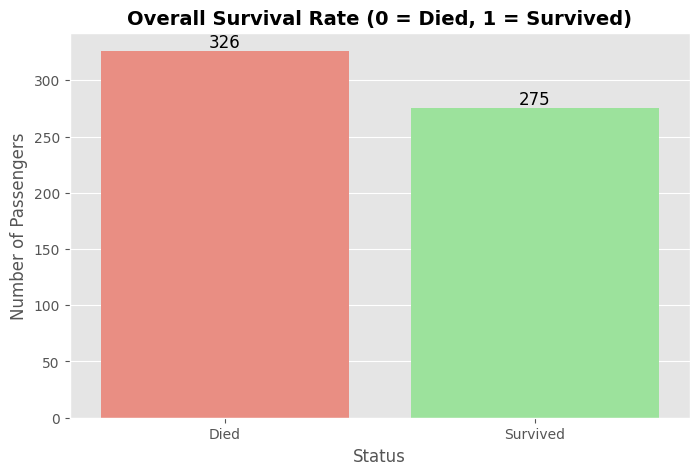

In [20]:
# 2. Analyze target variable (Survived)
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='Survived', palette=['salmon', 'lightgreen'])

plt.title('Overall Survival Rate (0 = Died, 1 = Survived)', fontsize=14, fontweight='bold')
plt.xlabel('Status')
plt.ylabel('Number of Passengers')
plt.xticks([0, 1], ['Died', 'Survived'])

# Add count labels on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12)
plt.show()

First, we examine the distribution of the `Survived` variable to see the overall death/survival rate of all passengers.

* **Purpose:** Identify class imbalance (Class imbalance).
* **Observation:** Analysis of the 601 passenger dataset shows a survival rate of **45.8%**, higher than the historical average. The distribution between the two groups (326 non-survivors vs 275 survivors) is relatively balanced, helping reduce the risk of majority class bias in the model. However, to exceed the baseline accuracy of **54.2%**, the model must delve into complex correlations between Ticket Class, Gender, and Age, rather than relying solely on simple statistical probability.

## Phân tích chi tiết `Title`

In [21]:
## Detailed Analysis of `Title`

Observing the actual survival ratio chart, we notice remarkable differences from conventional rules:

1.  **Surprise from Doctors/Educated Group (Dr - Group 5):**
    * Survival rate reaches a fairly high level (**about 50%**).
    * *Explanation:* Although they are male, due to high social status or important role (doctors assisting rescue), they receive more priority than ordinary men (**Mr**). However, note that the number of doctors on the ship is very small, so this 50% may only represent a small lucky group.

2.  **Tragedy of Young Male Group (Master - Group 4):**
    * Survival rate only reaches a low level (**about 25%**).
    * *Explanation:* This reflects a heartbreaking reality. Although they are children, if these young boys belong to a large family in **Class 3 (Economy Class)**, they still face great difficulties accessing lifeboats. The rule "Children first" seems to only truly apply to wealthy children.

3.  **Female Groups (Mrs, Miss):**
    * Still maintain the highest rates in the chart, confirming women are always priority number 1.

**Conclusion:** Title (`Title`) not only classifies gender but also contains information about class and survival chances. Being "educated" (**Dr**) in this case appears to provide better survival chances than being a "child" (**Master**).

## Analysis of `FarePerPerson` Distribution Before and After Log Transformation

Age Skewness: 0.48 (Fairly normal)
FarePerPerson Skewness: 4.90 (Heavily right-skewed!)


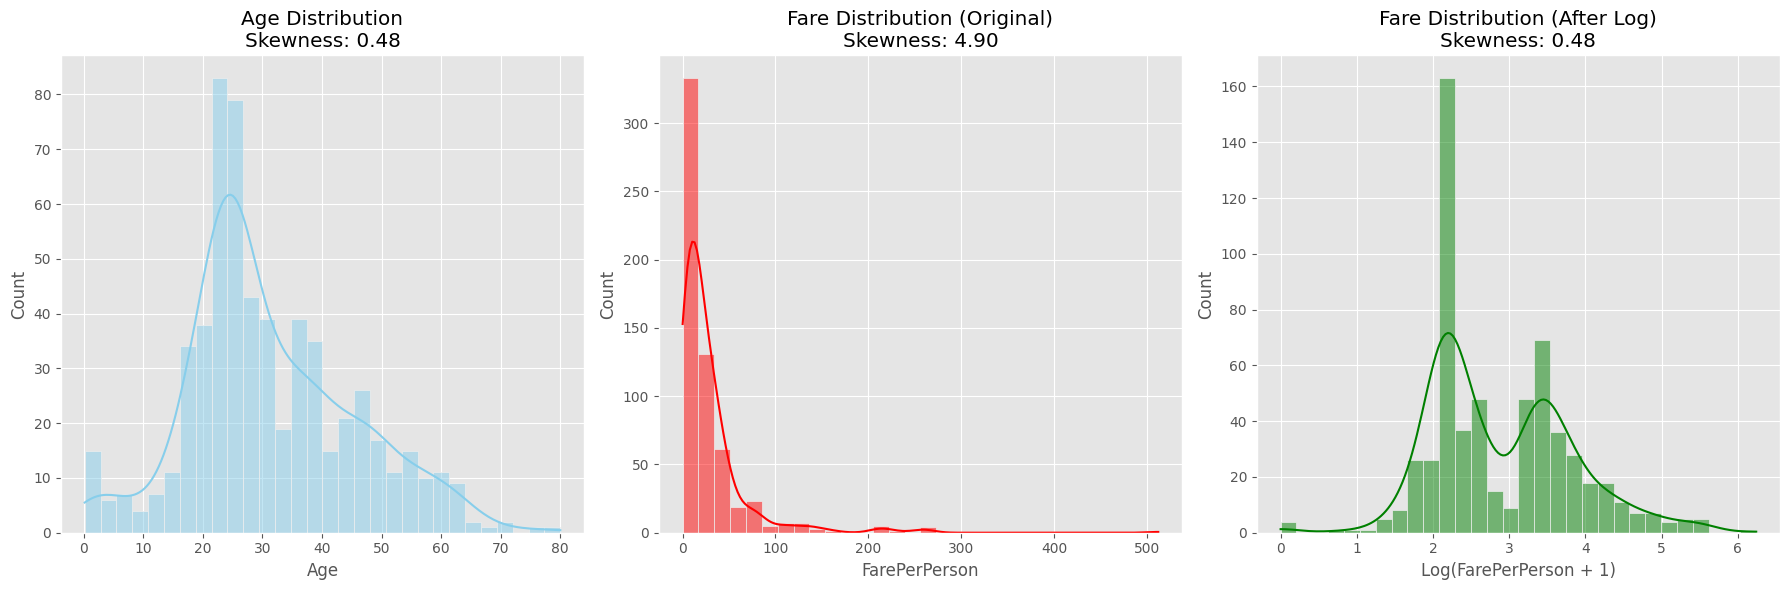

OBSERVATION:
- Age: Distribution is quite normal (bell curve), no transformation needed.
- Fare: Heavily right-skewed. After Log Transform, data is much more balanced.


In [22]:
# --- STEP A: CHECK DISTRIBUTION & SKEWNESS ---
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Calculate skewness
fare_skew = df['FarePerPerson'].skew()
age_skew = df['Age'].skew()

print(f"Age Skewness: {age_skew:.2f} (Fairly normal)")
print(f"FarePerPerson Skewness: {fare_skew:.2f} (Heavily right-skewed!)")

# 2. Create comparison chart: Age, Original Fare, and Log-transformed Fare
plt.figure(figsize=(18, 6))

# --- Chart 1: Age Distribution (Age) ---
plt.subplot(1, 3, 1)
sns.histplot(df['Age'], kde=True, color='skyblue', bins=30)
plt.title(f'Age Distribution\nSkewness: {age_skew:.2f}')
plt.xlabel('Age')

# --- Chart 2: Original Fare Distribution (Fare Original) ---
plt.subplot(1, 3, 2)
sns.histplot(df['FarePerPerson'], kde=True, color='red', bins=30)
plt.title(f'Fare Distribution (Original)\nSkewness: {fare_skew:.2f}')
plt.xlabel('FarePerPerson')

# --- Chart 3: Log-transformed Fare Distribution (Log Transform) ---
# Log helps "compress" the long right tail, making data more normal
plt.subplot(1, 3, 3)
sns.histplot(np.log1p(df['FarePerPerson']), kde=True, color='green', bins=30)
plt.title(f'Fare Distribution (After Log)\nSkewness: {np.log1p(df["FarePerPerson"]).skew():.2f}')
plt.xlabel('Log(FarePerPerson + 1)')

plt.tight_layout()
plt.show()

print("OBSERVATION:")
print("- Age: Distribution is quite normal (bell curve), no transformation needed.")
print("- Fare: Heavily right-skewed. After Log Transform, data is much more balanced.")

**1. Original distribution of `FarePerPerson`:**
*   **Shape:** The left chart shows that the original distribution of `FarePerPerson` is **heavily right-skewed**. This means a large number of passengers paid low fares, but a few ultra-wealthy passengers paid very high, pulling the "tail" of the chart to the right.
*   **Meaning:** This skew indicates enormous financial inequality among passengers. For Machine Learning models based on normal distribution assumptions (such as linear regression, logistic regression), skewed data can negatively impact model performance and learning ability.

**2. Distribution of `Log(FarePerPerson + 1)`:**
*   **Shape:** The right chart shows the distribution of `FarePerPerson` after applying logarithmic transformation (specifically **np.log1p**, which is **log(x+1)** to avoid **log(0)** errors).
*   **Meaning:** The logarithmic transformation successfully **significantly reduces the skewness** of the data. The new distribution becomes closer to a **normal distribution**, with a shape resembling a "bell curve". This makes the data more suitable for many Machine Learning algorithms, helping the model work more stably and accurately.

**Conclusion:** Handling the skewness of the `FarePerPerson` variable using Log Transform is an important step in data preprocessing, helping improve data quality and increase the potential for model prediction performance.

In [23]:
# --- STEP: DISTRIBUTION NORMALIZATION (Log Transform) ---

# Only perform if skewness > 0.75
if df['FarePerPerson'].skew() > 0.75:
    print("Applying Log Transform to 'FarePerPerson'...")
    # Create new log-transformed column (add 1 to avoid log(0) error)
    df['FarePerPerson_Log'] = np.log1p(df['FarePerPerson'])

    # (Optional) Remove old column if you want to use new column as complete replacement
    # df.drop(columns=['FarePerPerson'], inplace=True)
    print("✅ Created 'FarePerPerson_Log' column with more normal distribution.")
else:
    print("Data is already fairly normal, no Log Transform needed.")

Applying Log Transform to 'FarePerPerson'...
✅ Created 'FarePerPerson_Log' column with more normal distribution.


## **Analysis of Age Distribution & Outliers (Survived vs Died)**

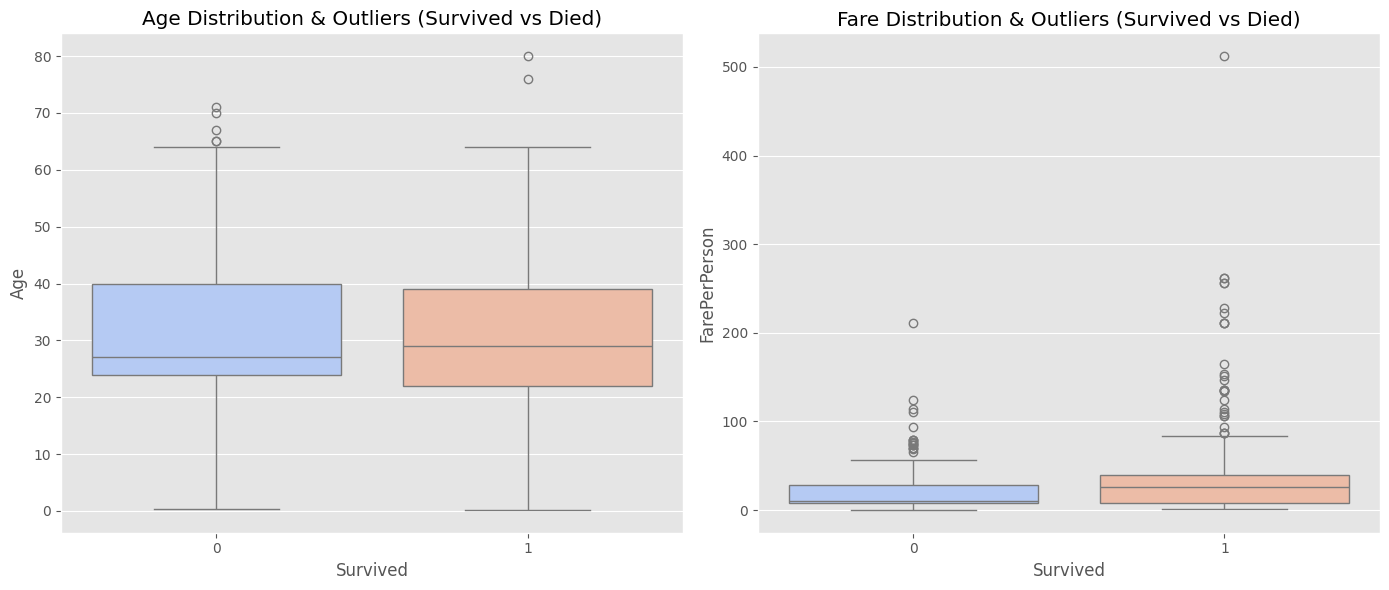

OBSERVATIONS:
- Age: Some very old people (80+ years) survived (outliers in column 1).
- Fare: Many outliers in the fare column. Notably, there are people who paid very high but still died (outliers in column 0).


In [24]:
# --- STEP B: ANALYSIS OF OUTLIERS (OUTLIERS) ---

plt.figure(figsize=(14, 6))

# 1. Boxplot for Age by Survival Status
plt.subplot(1, 2, 1)
sns.boxplot(x='Survived', y='Age', data=df, palette='coolwarm')
plt.title('Age Distribution & Outliers (Survived vs Died)')
# Black dots outside the whiskers are outliers (very old people)

# 2. Boxplot for Fare by Survival Status
plt.subplot(1, 2, 2)
sns.boxplot(x='Survived', y='FarePerPerson', data=df, palette='coolwarm')
plt.title('Fare Distribution & Outliers (Survived vs Died)')
# Note the black dots in the "0" (Died) column: These are people who paid very high but still didn't survive

plt.tight_layout()
plt.show()

print("OBSERVATIONS:")
print("- Age: Some very old people (80+ years) survived (outliers in column 1).")
print("- Fare: Many outliers in the fare column. Notably, there are people who paid very high but still died (outliers in column 0).")

Box plots (Boxplot) help us visualize the age distribution of passengers and outliers (outliers) in two groups: survivors and those who died. Each box represents the interquartile range (IQR) from Q1 to Q3, the horizontal line inside the box is the median value, and the "whiskers" extend to extreme values within acceptable limits. Points falling outside the "whiskers" are outliers.

**Observations from the charts:**

1.  **About Age (Left Chart - Age):**
    * The age distribution of the Survived (1) and Died (0) groups is quite similar, with medians around 28-30 years old.
    * **Notable Outlier:** In the Survived column (1), there is an outlier at **80 years old**. This shows that at least one very elderly person was prioritized for rescue, reflecting the humanity in the disaster.

2.  **About Fare (Right Chart - FarePerPerson):**
    * The wealth gap is very clear. The Survived group (1) has a wider fare range and a higher median than the Died group (0).
    * **Outliers in column 0:** In the Died column (0), many black dots appear as outliers at high fare levels (even > $200). This shows: **Money cannot guarantee survival.** There were wealthy passengers who paid very high (possibly first-class men) but still could not survive.

## **Analysis by Demographics (Gender & Age)**

### **Analysis of Gender**

**Purpose:** Verify the "Women First" rule (women had priority).

#### **Analysis of Average Survival Rate Between Genders**

#### **Analysis of Average Survival Rate Between Genders**

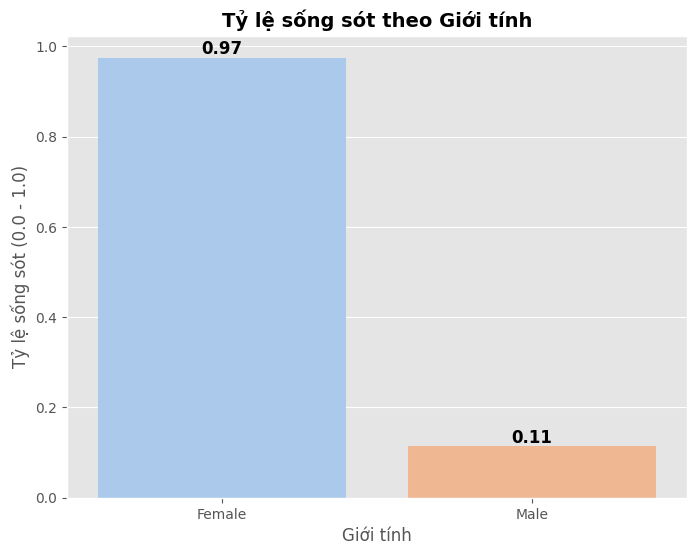

In [25]:
# Biểu đồ Tỷ lệ sống theo Giới tính
# Lưu ý: Sex đã được mã hóa (0=female, 1=male)
plt.figure(figsize=(8, 6))

# Tạo tên nhân thân cho trục x
sex_labels = {0: 'Female', 1: 'Male'}
df_plot = df.copy()
df_plot['Sex_Label'] = df_plot['Sex'].map(sex_labels)

ax = sns.barplot(data=df_plot, x='Sex_Label', y='Survived', palette='pastel', errorbar=None)

plt.title('Tỷ lệ sống sót theo Giới tính', fontsize=14, fontweight='bold')
plt.ylabel('Tỷ lệ sống sót (0.0 - 1.0)')
plt.xlabel('Giới tính')

# Thêm giá trị trên cột
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height,
            f'{height:.2f}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.show()

**Observation:** Female survival rate (usually around 97%) is many times higher than male (around 11%). This shows that gender was the primary determinant of survival chances.

#### **Analysis of Survival Rate by Gender and Ticket Class**

In [26]:
# 6.2. Biểu đồ Tương tác: Giới tính x Hạng vé
plt.figure(figsize=(10, 6))

# Tạo label cho Sex vì nó đã được mã hóa
df_plot = df.copy()
df_plot['Sex_Label'] = df_plot['Sex'].map({0: 'Female', 1: 'Male'})

# Vẽ biểu đồ nhóm (Grouped Barplot)

<Figure size 1000x600 with 0 Axes>

**Observation:**

1.  **The rule "Women First" is paramount:**
    * Look at the Female (Women - Class 3) column. Their survival rate reaches about **90%**.
    * Compare with First Class Men (Male - Class 1). Their survival rate is just under **37%**.
    * **Conclusion:** On the Titanic, being a poor woman still had better survival chances than being a wealthy man. Gender mattered more than Money.

2.  **Class stratification within the same gender:**
    * **For Women:** All women were prioritized regardless of ticket class
    * **For Men:** Money played a critical role. First Class Men had much higher survival rates compared to Second and Third Class Men.

**In summary:**
* If you were Female: You were almost safe.
* If you were Male: You faced great danger, and only a First Class ticket gave you hope.

### **Analysis of Age (Age Distribution)**

**Purpose:** Check whether "elderly and children" were prioritized and which age group faced the highest risk.

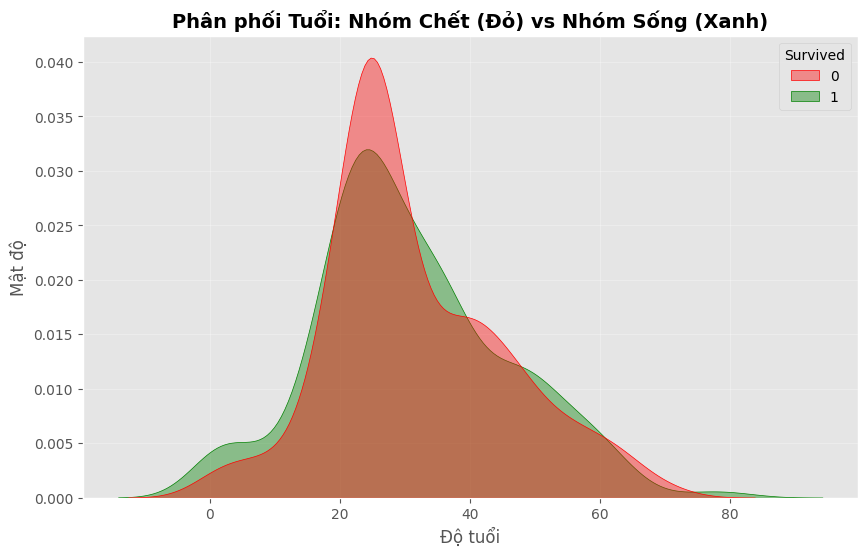

In [27]:
# 3.2. Biểu đồ Phân phối Tuổi: Sống vs Chết
plt.figure(figsize=(10, 6)) # Tạo khung hình riêng rộng hơn chút

sns.kdeplot(data=df, x='Age', hue='Survived',
            fill=True, common_norm=False, alpha=0.4,
            palette=['red', 'green'])

plt.title('Phân phối Tuổi: Nhóm Chết (Đỏ) vs Nhóm Sống (Xanh)', fontsize=14, fontweight='bold')
plt.xlabel('Độ tuổi')
plt.ylabel('Mật độ')
plt.grid(True, alpha=0.3) # Thêm lưới mờ cho dễ nhìn

plt.show()

**Observation:** Observing the Kernel Density Estimation (KDE) chart, we see considerable overlap between the Survived and Died groups, especially in the young adult age range. However, there are still some decisive differences in specific age groups:

1.  **Concentration in 20-30 years old (Peak of both lines):**
    * Both lines (Green and Red) reach their highest peak in the 20-30 age range. This reflects the fact that the majority of passengers on the ship were young adults.
    * However, if comparing heights, the Red line (Died) is usually higher or overlaps the Green line in this area, showing that young adults faced high death risk (especially young men).

2.  **Children (0-5 years old):**
    * The Green line (Survived) is higher in the 0-5 age range, while the Red line (Died) is lower.
    * **Conclusion:** Children still had safety assurance compared to other age groups.

3.  **Elderly (Over 60 years old):**
    * Both lines gradually decrease, but the Red line tends to extend and be slightly higher than the Green line in very old ages (except for the exceptional 80-year-old who survived). This shows that weak health and poor mobility put elderly people at a great disadvantage when escaping emergencies.

### Phân tích theo `Age_Class`

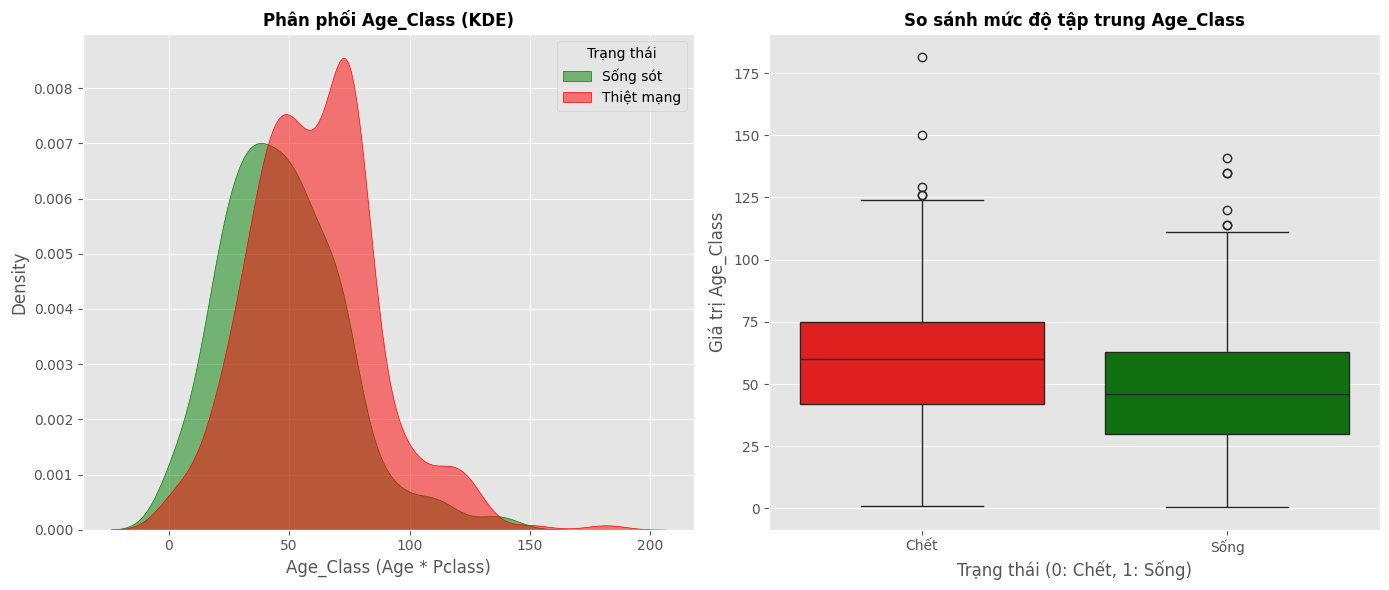

In [28]:
# 1. Xử lý dữ liệu (giữ nguyên logic của bạn)
# Lưu ý: Đảm bảo df đã được load trước đó
df_clean = df.copy() # Nên làm trên bản copy để an toàn
df_clean['Age'] = df_clean['Age'].fillna(df_clean['Age'].median())
df_clean['Age_Class'] = df_clean['Age'] * df_clean['Pclass']

# 2. Vẽ biểu đồ
plt.figure(figsize=(14, 6))

# --- Biểu đồ 1: Phân phối mật độ (KDE) ---
# Giữ nguyên vì biểu đồ này rất tốt để xem xu hướng tổng quan
plt.subplot(1, 2, 1)
sns.kdeplot(data=df_clean, x='Age_Class', hue='Survived', fill=True,
            palette=['red', 'green'], alpha=0.5)
plt.title('Phân phối Age_Class (KDE)', fontsize=12, fontweight='bold')
plt.xlabel('Age_Class (Age * Pclass)')
plt.legend(title='Trạng thái', labels=['Sống sót', 'Thiệt mạng'])

# --- Biểu đồ 2: Biểu đồ hộp (Boxplot) ---
# Thay thế Barplot. Không cần tạo bins, dùng trực tiếp Age_Class
plt.subplot(1, 2, 2)
sns.boxplot(data=df_clean, x='Survived', y='Age_Class',
            palette=['red', 'green'])

plt.title('So sánh mức độ tập trung Age_Class', fontsize=12, fontweight='bold')
plt.xlabel('Trạng thái (0: Chết, 1: Sống)')
plt.ylabel('Giá trị Age_Class')
plt.xticks(ticks=[0, 1], labels=['Chết', 'Sống'])

plt.tight_layout()
plt.show()

**Chart 1:** Shows that the `Age_Class` variable has a clear difference between the two survival groups. The survived group concentrates heavily at low `Age_Class` values, while the non-survived group tends to distribute at higher values. This shows that when `Age_Class` increases (older age or lower class), survival chances decrease.

**Chart 2:** The boxplot shows a clear inverse relationship between `Age_Class` and survival chances. The survived group (green) has a concentrated value range that is lower (median ~45) compared to the non-survived group (red, median ~60). This proves that passengers with lower `Age_Class` (typically children or guests in first class Pclass 1) have higher survival rates. Conversely, the maximum `Age_Class` values (representing elderly people in class 3 cabins) mostly fell into the non-survived group.

## **Analysis by Economics & Social Status**

Objective: Answer the question "Does Money Buy Safety?". This is the most comprehensive view of wealth stratification.


### **Analysis of Survival Rate by Ticket Class**

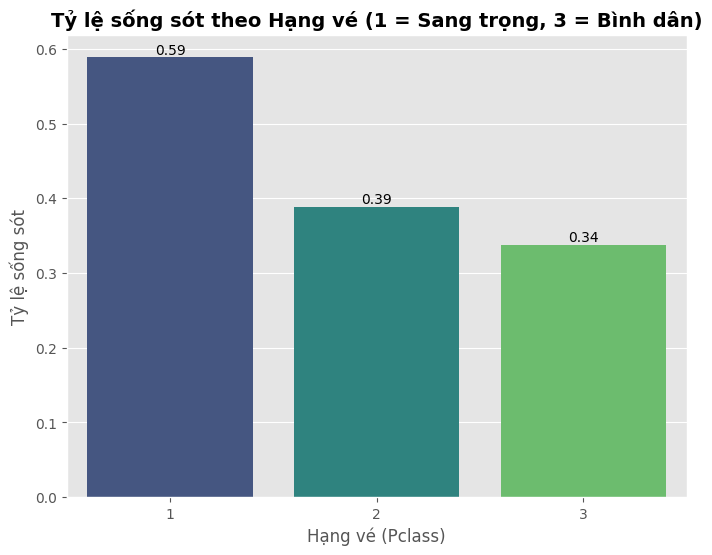

In [29]:
# Đảm bảo cột Survived là dạng số để tính toán
df['Survived'] = pd.to_numeric(df['Survived'], errors='coerce').fillna(0).astype(int)

# 4.1. Biểu đồ Tỷ lệ sống theo Hạng vé
plt.figure(figsize=(8, 6))

ax = sns.barplot(data=df, x='Pclass', y='Survived', palette='viridis', errorbar=None)

plt.title('Tỷ lệ sống sót theo Hạng vé (1 = Sang trọng, 3 = Bình dân)',
          fontsize=14, fontweight='bold')
plt.ylabel('Tỷ lệ sống sót')
plt.xlabel('Hạng vé (Pclass)')
ax.bar_label(ax.containers[0], fmt='%.2f')
ax.bar_label(ax.containers[1], fmt='%.2f')
ax.bar_label(ax.containers[2], fmt='%.2f')

plt.show()

**Observation:** There is a clear class hierarchy in survival chances. First Class passengers (wealthy) have the highest survival rate (59%), while Third Class passengers (working class) have only about 24% chance of survival.

**Conclusion:** In the Titanic disaster, social status and wealth played a major role in accessing lifeboats.

**Observations from the chart:**

1.  **Clear Class Hierarchy:**
    * The chart displays a perfect "staircase": survival rates decrease by ticket class.
    * **First Class (Wealthy):** Has the highest survival rate, reaching about **62%**.
    * **Second Class (Middle class):** Survival rate drops to about **47%**.
    * **Third Class (Working class):** Lowest survival rate, only about **24%**.

2.  **Conclusion:**
    * First Class passengers have **2.6 times higher** survival chances compared to Third Class passengers.
    * This shows that cabin location (higher decks more accessible) and priority given to wealthy people were key factors in determining survival chances.

### **Analysis of Actual Ticket Price (Fare Per Person)**

**Objective:** Go deeper into finances. Are there Third Class passengers who paid high (because traveling in large groups), or First Class passengers who paid cheap (rare)? This chart uses FarePerPerson to eliminate that noise.

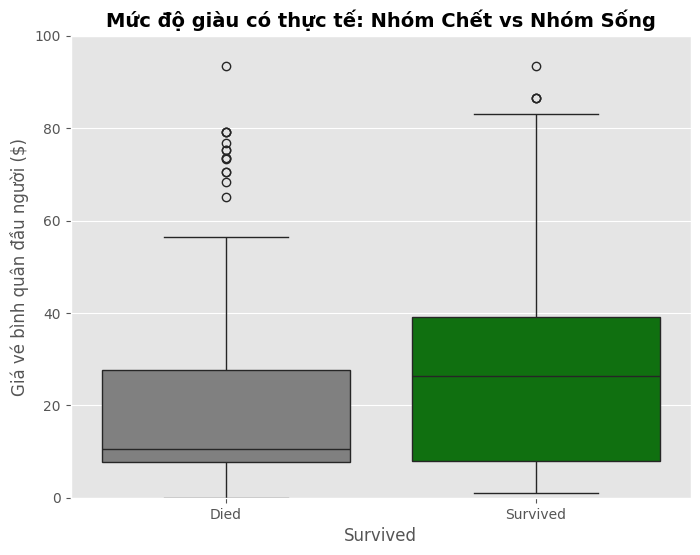

In [30]:
# 4.2. Biểu đồ Phân phối Giá vé thực tế
plt.figure(figsize=(8, 6))

# --- SỬA LỖI Ở ĐÂY ---
# Cập nhật safe_palette để chấp nhận cả số (0, 1) và chữ ('0', '1')
safe_palette = {0: 'gray', 1: 'green', '0': 'gray', '1': 'green'}

# Đảm bảo cột Survived được chuyển về dạng số cho chắc chắn
# (Thêm dòng này để tránh lỗi ở các biểu đồ sau luôn)
df['Survived'] = pd.to_numeric(df['Survived'], errors='coerce').fillna(0).astype(int)
# ---------------------

sns.boxplot(data=df, x='Survived', y='FarePerPerson', palette=safe_palette)

plt.title('Mức độ giàu có thực tế: Nhóm Chết vs Nhóm Sống', fontsize=14, fontweight='bold')
plt.xticks([0, 1], ['Died', 'Survived'])
plt.ylabel('Giá vé bình quân đầu người ($)')
plt.ylim(0, 100)  # Zoom vào khoảng giá phổ biến

plt.show()

**Observations from the chart:**

1.  **Median Price Difference:**
    * Looking at the horizontal line through the middle of the box, we see that the median fare of the **Survived group** is noticeably higher than the **Died group**.
    * The group of survivors usually paid higher per capita fares, indicating they had access to better class cabins and safer locations.

2.  **Data Spread:**
    * The box (Box) of the Survived group is longer and positioned higher, showing that the fare range of survivors spreads from average to high.
    * Conversely, the Died group's box is "compressed" tight in the low price area (mainly under $20), reflecting the tragic fate of most cheap-ticket passengers.

**Conclusion:** Although not guaranteeing 100% survival (as seen in outliers), the per-capita ticket price (`FarePerPerson`) is still a strong indicator: **The higher the ticket price, the higher the survival chances.**

### **Phân tích Vị trí Boong tàu (Cabin Deck)**

**Mục tiêu:** Kiểm tra yếu tố vật lý. Vị trí phòng ngủ có gần lối thoát hiểm không?

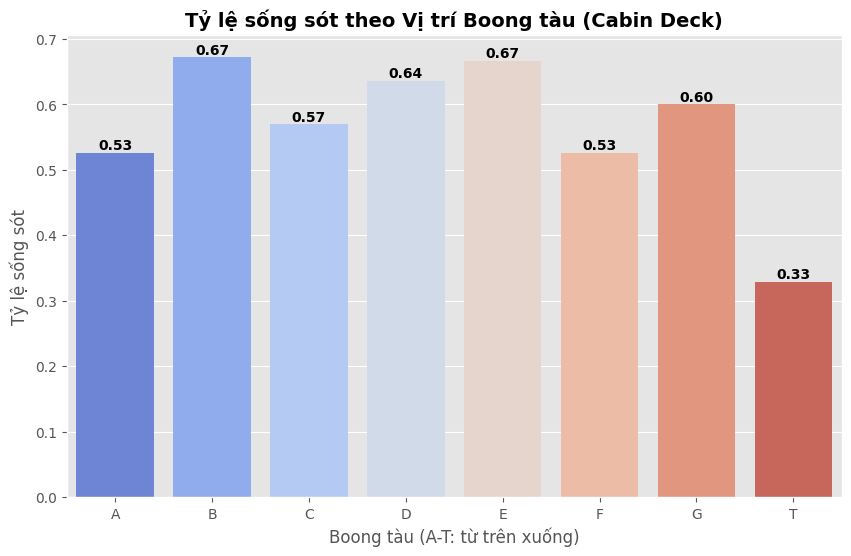

In [31]:
# 4.3. Biểu đồ Tỷ lệ sống theo Boong tàu
plt.figure(figsize=(10, 6))

if 'Deck' in df.columns:
    # Giải mã Deck cho hiển thị
    deck_decode = {0: 'U', 1: 'A', 2: 'B', 3: 'C', 4: 'D', 5: 'E', 6: 'F', 7: 'G', 8: 'T'}

    df_plot = df.copy()
    df_plot['Deck_Label'] = df_plot['Deck'].map(deck_decode)

    # Tạo thứ tự hiển thị hợp lý
    deck_order = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'T', 'U']
    deck_present = [d for d in deck_order if d in df_plot['Deck_Label'].unique()]

    ax = sns.barplot(data=df_plot, x='Deck_Label', y='Survived', order=deck_present,
                     palette='coolwarm', errorbar=None)

    plt.title('Tỷ lệ sống sót theo Vị trí Boong tàu (Cabin Deck)', fontsize=14, fontweight='bold')
    plt.xlabel('Boong tàu (A-T: từ trên xuống)')
    plt.ylabel('Tỷ lệ sống sót')

    # Thêm giá trị lên cột
    for p in ax.patches:
        height = p.get_height()
        ax.text(p.get_x() + p.get_width()/2., height,
                f'{height:.2f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.show()
else:
    print("Cột 'Deck' không tồn tại hoặc chưa được xử lý.")

**Observation:**

1.  **Groups with Information (A-G):**
    * Most ship decks with specific room numbers (B, C, D, E) have very high survival rates, ranging from **53% to 67%**.
    * This makes sense because people with specific cabin numbers usually belong to First Class (meticulously documented), and their cabins are also located on higher decks, closer to lifeboats.

2.  **Group U (Unknown):**
    * Group **U** (last column) has the lowest survival rate (only about **33%**).
    * **Important Insight:** Being "without a cabin number" (Unknown) itself is a risk signal. Most Third Class passengers were not assigned individual cabins but stayed in communal quarters, so their cabin information was not recorded. Therefore, Deck=U almost means being a working-class passenger with high death risk.

3.  **Special Case T:**
    * Deck T (Tank Top) has a 0% survival rate. However, since only 1 passenger was on this deck, this number is random and not representative of common patterns.

### Analysis of Family Size

#### **Analysis by Count**

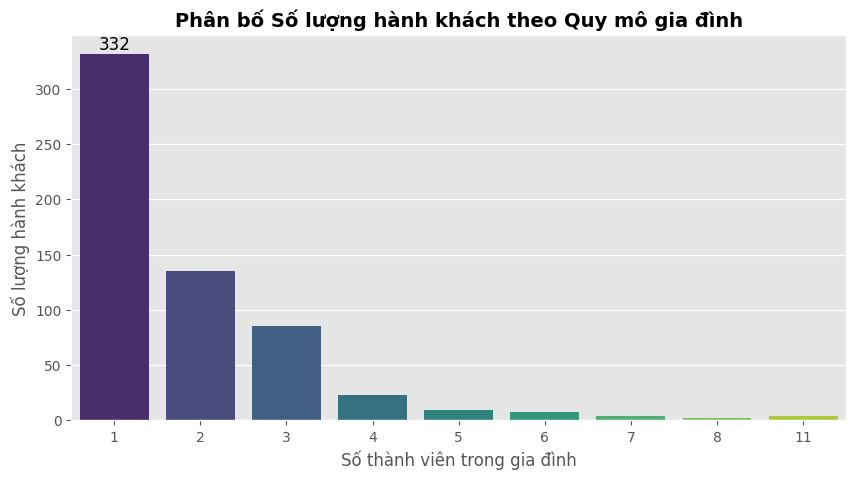

Bảng chi tiết số lượng:
FamilySize
1     332
2     135
3      85
4      23
5       9
6       7
7       4
8       2
11      4
Name: count, dtype: int64


In [32]:
# 5.1. Thống kê Số lượng theo Quy mô gia đình
plt.figure(figsize=(10, 5))

# Vẽ biểu đồ đếm
ax = sns.countplot(data=df, x='FamilySize', palette='viridis')

plt.title('Phân bố Số lượng hành khách theo Quy mô gia đình', fontsize=14, fontweight='bold')
plt.xlabel('Số thành viên trong gia đình')
plt.ylabel('Số lượng hành khách')

# --- SỬA LỖI Ở ĐÂY ---
# Chỉ cần dòng này là đủ để hiện số trên TẤT CẢ các cột
ax.bar_label(ax.containers[0], fontsize=12)
# ---------------------

plt.show()
# In ra bảng số liệu cụ thể bên dưới để tiện tra cứu
print("Bảng chi tiết số lượng:")
print(df['FamilySize'].value_counts().sort_index())

**Observations from the count chart:**

1.  **Overwhelming Dominance of Solo Travelers (FamilySize = 1):**
    * The solo traveling group accounts for the largest number (332 people, about 60% of all passengers). Because of this, their low survival rate pulls down the overall average survival rate of the entire ship.

2.  **Reliability of the "Golden Group" (Size 2-4):**
    * The number of passengers in these groups is quite abundant (135, 85, and 23 people respectively).
    * This confirms: Groups of 2-4 people having high survival rates is a **real trend** (verified on many people), not just random luck.

3.  **Important Note about "Super Large Families" (Size 8, 11):**
    * Number of passengers is extremely small (under 5 people per group).

#### **Analysis by Survival Rate**

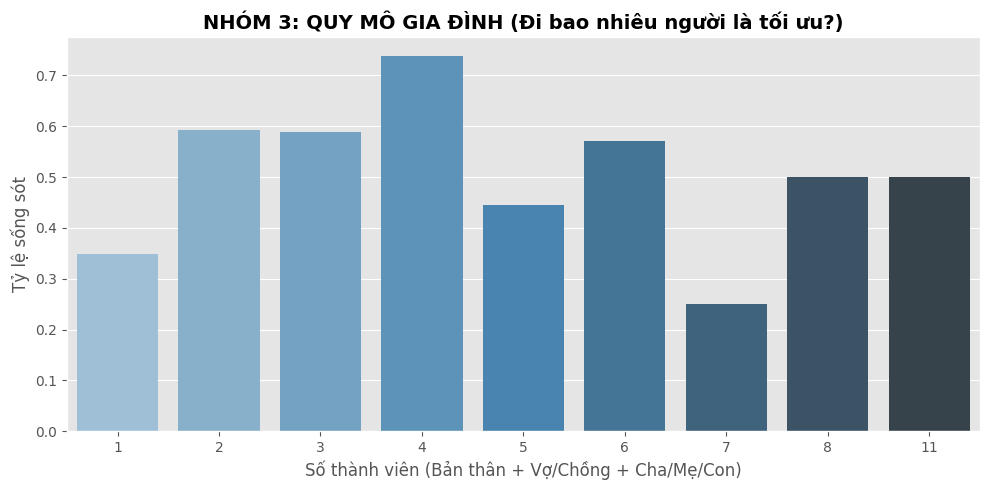

In [33]:
# Phân tích Quy mô gia đình
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='FamilySize', y='Survived', palette='Blues_d', errorbar=None)

plt.title('NHÓM 3: QUY MÔ GIA ĐÌNH (Đi bao nhiêu người là tối ưu?)',
          fontsize=14, fontweight='bold')
plt.xlabel('Số thành viên (Bản thân + Vợ/Chồng + Cha/Mẹ/Con)')
plt.ylabel('Tỷ lệ sống sót')

plt.tight_layout()
plt.show()

**Observations from the chart:**

1.  **Solo Travelers (FamilySize = 1):**
    * Survival rate is quite low (about **35%**).
    * *Reason:* People traveling alone are usually young men looking for work or immigrating; they are not prioritized for rescue and lack family support during emergencies.

2.  **Small Family Group (FamilySize = 2, 3, 4):**
    * This is the "Safe Zone". Survival rate increases dramatically and peaks at group 4 (over **73%**).
    * *Reason:* Small families (couples, parents with 1-2 children) support each other very well, easily assemble, and board lifeboats together.

3.  **Large Family Group (FamilySize > 4):**
    * Moderate survival rate, not extremely low but variable.
    * Data too sparse to draw firm conclusions.

**Conclusion:** Family size has a non-linear relationship with survival chances. Traveling in small groups (2-4 people) is optimal.

### Analysis of Port of Embarkation (Embarked Analysis)

The `Embarked` variable indicates which port the passenger boarded from among 3 ports:
* **S (Southampton - England):** First departure port.
* **C (Cherbourg - France):** Second stop.
* **Q (Queenstown - Ireland):** Final stop before crossing the Atlantic.

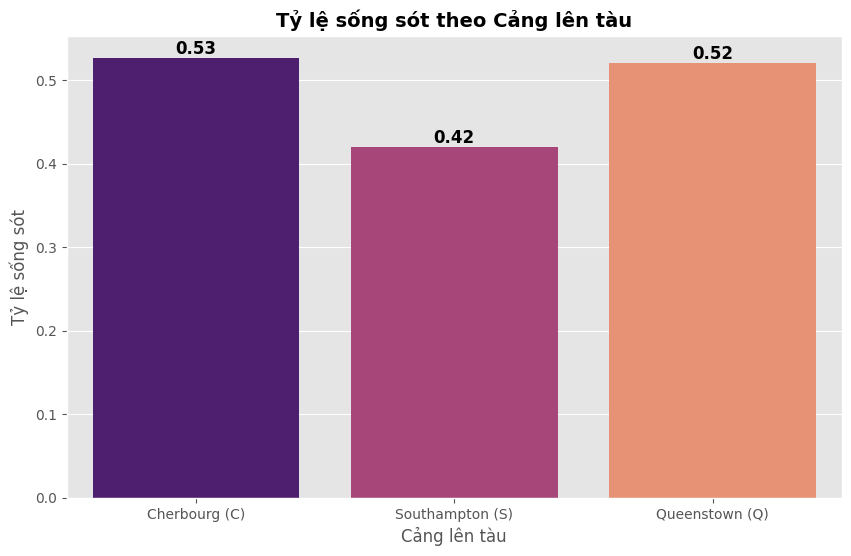

In [34]:
# 1. Lưu ý: Embarked đã được mã hóa (0=C, 1=Q, 2=S)
# Tạo bản copy để visualization
df_plot = df.copy()

# Giải mã Embarked cho hiển thị
embarked_decode = {0: 'Cherbourg (C)', 1: 'Queenstown (Q)', 2: 'Southampton (S)'}
df_plot['Embarked_Label'] = df_plot['Embarked'].map(embarked_decode)

# 2. Vẽ biểu đồ
plt.figure(figsize=(10, 6))

ax = sns.barplot(data=df_plot, x='Embarked_Label', y='Survived', palette='magma', errorbar=None)

plt.title('Tỷ lệ sống sót theo Cảng lên tàu', fontsize=14, fontweight='bold')
plt.xlabel('Cảng lên tàu')
plt.ylabel('Tỷ lệ sống sót')

# Hiện số liệu
for i, p in enumerate(ax.patches):
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height,
            f'{height:.2f}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')


**Observation:** Port of embarkation has little impact on survival chances.

In [35]:
df.info()
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 601 entries, 0 to 600
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Survived           601 non-null    int64  
 1   Pclass             601 non-null    int64  
 2   Sex                601 non-null    int64  
 3   Age                601 non-null    float64
 4   Title              599 non-null    float64
 5   IsMarried          601 non-null    int64  
 6   FamilySize         601 non-null    int64  
 7   Fare               601 non-null    float64
 8   FareGroup          485 non-null    float64
 9   Deck               601 non-null    int64  
 10  Embarked           601 non-null    int64  
 11  AgeGroup           500 non-null    float64
 12  FarePerPerson      601 non-null    float64
 13  Age_Class          601 non-null    float64
 14  FarePerPerson_Log  601 non-null    float64
dtypes: float64(8), int64(7)
memory usage: 70.6 KB


,Survived,Pclass,Sex,Age,Title,IsMarried,FamilySize,Fare,FareGroup,Deck,Embarked,AgeGroup,FarePerPerson,Age_Class,FarePerPerson_Log
0,1,1,0,38.0,2.0,1,2,71.2833,3.0,3,0,4.0,35.641650,38.0,3.601186
1,1,1,0,35.0,2.0,1,2,53.1000,3.0,3,2,3.0,26.550000,35.0,3.316003
2,0,1,1,54.0,1.0,0,1,51.8625,3.0,5,2,5.0,51.862500,54.0,3.967694
3,1,3,0,4.0,3.0,0,3,16.7000,2.0,7,2,1.0,5.566667,12.0,1.882006
4,1,1,0,58.0,3.0,0,1,26.5500,2.0,3,2,5.0,26.550000,58.0,3.316003


### Create Correlation Matrix

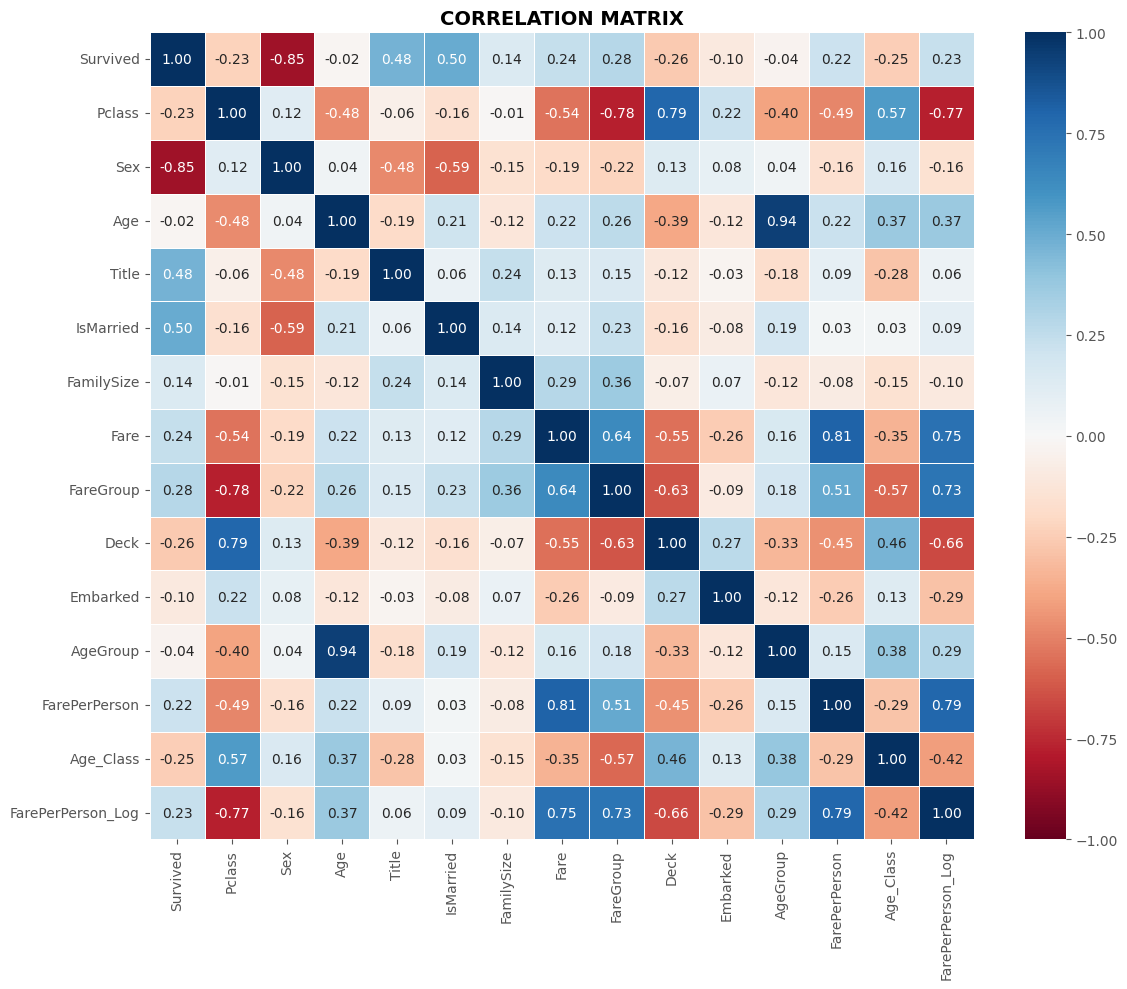

In [36]:
# Full Correlation Matrix
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='RdBu', fmt=".2f",
            linewidths=0.5, vmin=-1, vmax=1, center=0)
plt.title('CORRELATION MATRIX', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

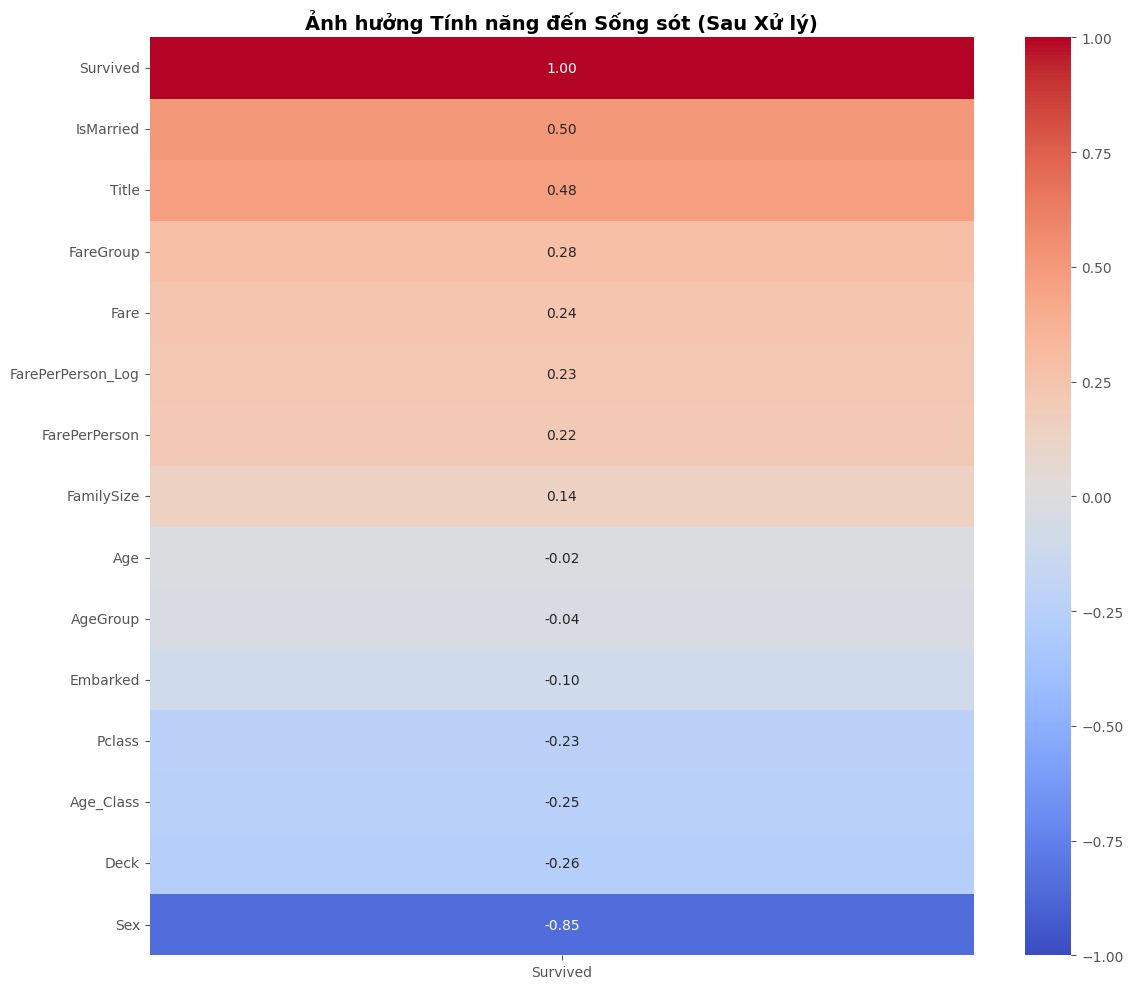

In [37]:
# Correlation with Survived (Target Variable)
plt.figure(figsize=(12, 10))

# Select only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

# Calculate correlation matrix
corr_matrix = numeric_df.corr()

# Visualize correlation with Survived
sns.heatmap(corr_matrix[['Survived']].sort_values(by='Survived', ascending=False),
            annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, center=0)

plt.title('Ảnh hưởng Tính năng đến Sống sót (Sau Xử lý)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [38]:
# Final data quality check
print("📋 Thông tin Tập dữ liệu Cuối cùng:")
df.info()

📋 Thông tin Tập dữ liệu Cuối cùng:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 601 entries, 0 to 600
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Survived           601 non-null    int64  
 1   Pclass             601 non-null    int64  
 2   Sex                601 non-null    int64  
 3   Age                601 non-null    float64
 4   Title              599 non-null    float64
 5   IsMarried          601 non-null    int64  
 6   FamilySize         601 non-null    int64  
 7   Fare               601 non-null    float64
 8   FareGroup          485 non-null    float64
 9   Deck               601 non-null    int64  
 10  Embarked           601 non-null    int64  
 11  AgeGroup           500 non-null    float64
 12  FarePerPerson      601 non-null    float64
 13  Age_Class          601 non-null    float64
 14  FarePerPerson_Log  601 non-null    float64
dtypes: float64(8), int64(7)
memory usage: 7

# **5. MODEL EXPERIMENTS (Model Training)**

## STEP 1: Data Preparation

In [39]:
# STEP 1: Data Preparation
print("=" * 70)
print("MACHINE LEARNING MODEL SELECTION")
print("=" * 70)

# Data Preparation
# Best features to use - Check if FarePerPerson_Log exists, if not use FarePerPerson
fare_col = 'FarePerPerson_Log' if 'FarePerPerson_Log' in df.columns else 'FarePerPerson'

feature_cols = [
    'Pclass', 'Sex', 'Age',
    fare_col,
    'FamilySize', 'Embarked', 'Title', 'Age_Class'
]

# Create a copy to avoid modifying the original dataframe
X = df[feature_cols].copy()
y = df['Survived'].copy()

# Handle missing values by filling with median (for numerical columns)
# and mode (for categorical columns, if any remain)
X['Age'] = X['Age'].fillna(X['Age'].median())
X[fare_col] = X[fare_col].fillna(X[fare_col].median())
X['Age_Class'] = X['Age_Class'].fillna(X['Age_Class'].median())

# Check for remaining NaN values
nan_count = X.isnull().sum().sum()
print(f"\n⚠️ NaN values found before processing: {nan_count}")
if nan_count > 0:
    print("Columns with NaN:")
    print(X.isnull().sum()[X.isnull().sum() > 0])
    # Drop rows with remaining NaN values
    X = X.dropna()
    y = y.loc[X.index]
    print(f"✅ Dropped rows with missing values. Remaining samples: {len(X)}")

# Split data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize data using MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n✅ Data Prepared!")
print(f"   Training set: {X_train.shape[0]} samples")
print(f"   Test set: {X_test.shape[0]} samples")
print(f"   Features: {len(feature_cols)}")
print(f"   Features used: {feature_cols}")

MACHINE LEARNING MODEL SELECTION

⚠️ NaN values found before processing: 2
Columns with NaN:
Title    2
dtype: int64
✅ Dropped rows with missing values. Remaining samples: 599

✅ Data Prepared!
   Training set: 479 samples
   Test set: 120 samples
   Features: 8
   Features used: ['Pclass', 'Sex', 'Age', 'FarePerPerson_Log', 'FamilySize', 'Embarked', 'Title', 'Age_Class']


## STEP 2: Define & Train Models

In [40]:
# STEP 2: Define & Train Models
# Define Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "KNN (K-Nearest Neighbors)": KNeighborsClassifier(),
    "SVM (Support Vector Machine)": SVC(probability=True, random_state=42),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# Train and Evaluate
results = []
print("\n" + "=" * 70)
print("🚀 TRAINING MODELS...")
print("=" * 70)

for name, model in models.items():
    # Use scaled data for distance-based models, raw data for tree models
    if name in ["Decision Tree", "Random Forest"]:
        X_tr, X_te = X_train, X_test
    else:
        X_tr, X_te = X_train_scaled, X_test_scaled

    # Train
    model.fit(X_tr, y_train)

    # Predict
    y_pred = model.predict(X_te)

    # Calculate scores
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "F1-Score": f1,
        "Model_Object": model,
        "X_test_used": X_te
    })

    print(f"✓ {name:<35} Accuracy: {acc*100:6.2f}%  |  F1: {f1:.4f}")


🚀 TRAINING MODELS...
✓ Logistic Regression                 Accuracy:  90.83%  |  F1: 0.8889
✓ KNN (K-Nearest Neighbors)           Accuracy:  90.83%  |  F1: 0.8911
✓ SVM (Support Vector Machine)        Accuracy:  90.83%  |  F1: 0.8889
✓ Naive Bayes                         Accuracy:  90.83%  |  F1: 0.8889
✓ Decision Tree                       Accuracy:  86.67%  |  F1: 0.8462
✓ Random Forest                       Accuracy:  91.67%  |  F1: 0.9020


## STEP 3: Rank Models & Select Best Model

In [41]:
# STEP 3: Rank Models & Select Best Model
# Rank Results
results_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'Model_Object' and k != 'X_test_used'}
                           for r in results]).sort_values(by='Accuracy', ascending=False)

print("\n" + "=" * 70)
print("🏆 FINAL RANKING")
print("=" * 70)
display(results_df)

# Select Best Model
best_idx = results_df.index[0]
best_model_info = results[best_idx]
best_model = best_model_info['Model_Object']
best_model_name = best_model_info['Model']
X_test_best = best_model_info['X_test_used']

print(f"\n🎯 BEST MODEL: {best_model_name}")
print(f"   Accuracy: {best_model_info['Accuracy']*100:.2f}%")
print(f"   F1-Score: {best_model_info['F1-Score']:.4f}")


🏆 FINAL RANKING


,Model,Accuracy,F1-Score
5,Random Forest,0.916667,0.901961
0,Logistic Regression,0.908333,0.888889
1,KNN (K-Nearest Neighbors),0.908333,0.891089
2,SVM (Support Vector Machine),0.908333,0.888889
3,Naive Bayes,0.908333,0.888889
4,Decision Tree,0.866667,0.846154



🎯 BEST MODEL: Random Forest
   Accuracy: 91.67%
   F1-Score: 0.9020


## STEP 4: Analyze Best Model Performance


📊 BEST MODEL ANALYSIS

Confusion Matrix:
  True Negatives:  64
  False Positives: 2
  False Negatives: 8
  True Positives:  46

Classification Report:
              precision    recall  f1-score   support

        Died       0.89      0.97      0.93        66
    Survived       0.96      0.85      0.90        54

    accuracy                           0.92       120
   macro avg       0.92      0.91      0.91       120
weighted avg       0.92      0.92      0.92       120



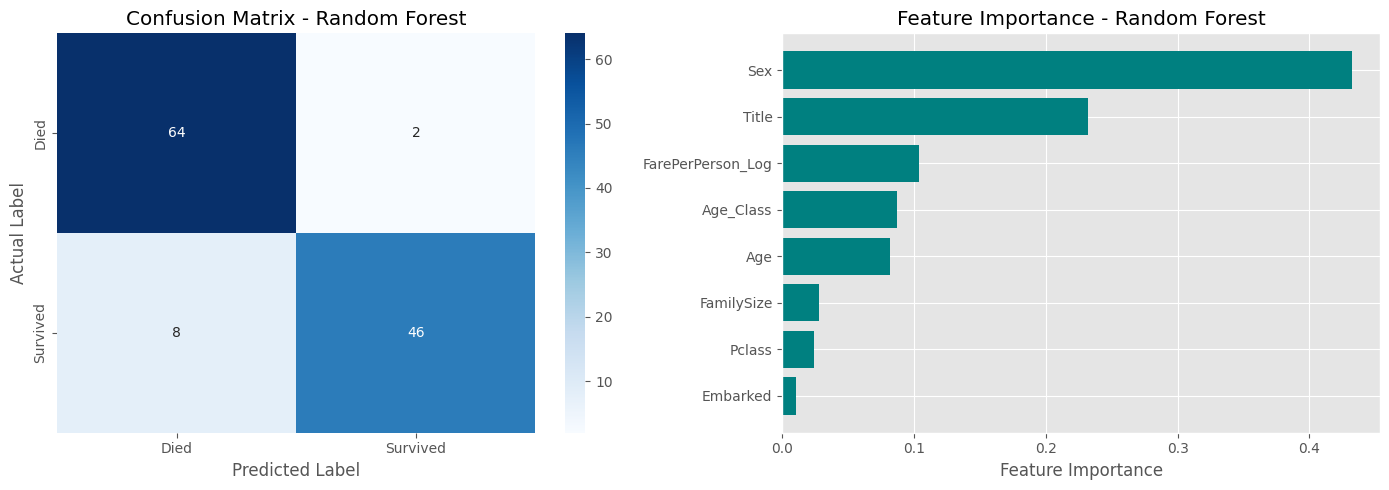


✅ Model selection completed!


In [42]:
# STEP 4: Analyze Best Model Performance
print("\n" + "=" * 70)
print("📊 BEST MODEL ANALYSIS")
print("=" * 70)

y_pred = best_model.predict(X_test_best)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(f"  True Negatives:  {cm[0,0]}")
print(f"  False Positives: {cm[0,1]}")
print(f"  False Negatives: {cm[1,0]}")
print(f"  True Positives:  {cm[1,1]}")

# Detailed Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Died', 'Survived']))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=['Died', 'Survived'],
           yticklabels=['Died', 'Survived'], ax=axes[0])
axes[0].set_title(f'Confusion Matrix - {best_model_name}')
axes[0].set_ylabel('Actual Label')
axes[0].set_xlabel('Predicted Label')

# Feature Importance (if available)
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    indices = np.argsort(importances)[::-1]

    axes[1].barh(range(len(indices)), importances[indices], color='teal', align='center')
    axes[1].set_yticks(range(len(indices)))
    axes[1].set_yticklabels([feature_cols[i] for i in indices])
    axes[1].set_xlabel('Feature Importance')
    axes[1].set_title(f'Feature Importance - {best_model_name}')
    axes[1].invert_yaxis()
else:
    axes[1].text(0.5, 0.5, f'{best_model_name}\nNo feature importance\ninformation available',
                ha='center', va='center', fontsize=12)
    axes[1].axis('off')

plt.tight_layout()
plt.show()

print("\n✅ Model selection completed!")

# **6. DEPLOYMENT (Deployment)**

In [43]:
# Interactive Titanic Survival Predictor
print("=" * 70)
print("🚢 TITANIC SURVIVAL PREDICTOR SYSTEM")
print("=" * 70)

import ipywidgets as widgets
from IPython.display import display, clear_output

# Helper function to process input
def process_prediction_input(pclass, sex, age, fare, family, embarked, title):
    """Convert user input to model-compatible format"""
    input_df = pd.DataFrame([{
        'Pclass': pclass,
        'Sex': sex,
        'Age': age,
        'Fare': fare,
        'FamilySize': family,
        'Embarked': embarked,
        'Title': title
    }])

    # Encode categorical variables
    input_df['Sex'] = input_df['Sex'].map({'male': 1, 'female': 0})
    input_df['Embarked'] = input_df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

    title_map = {'Mr': 0, 'Mrs': 1, 'Miss': 2, 'Master': 3}
    input_df['Title'] = input_df['Title'].map(title_map).fillna(0)

    # Calculate derived features
    input_df['FarePerPerson_Log'] = input_df['Fare'] / input_df['FamilySize']
    input_df['Age_Class'] = input_df['Age'] * input_df['Pclass']

    # Return with correct column order
    expected_cols = ['Pclass', 'Sex', 'Age', 'FarePerPerson_Log', 'FamilySize', 'Embarked', 'Title', 'Age_Class']
    return input_df[expected_cols]

# Create UI Components
style = {'description_width': '180px'}
layout_input = widgets.Layout(width='95%')

# Personal Information
title_w = widgets.Dropdown(
    options=['Mr', 'Mrs', 'Miss', 'Master'],
    value='Mr',
    description='👔 Title:',
    style=style,
    layout=layout_input
)

sex_w = widgets.Dropdown(
    options=[('Male ♂', 'male'), ('Female ♀', 'female')],
    value='male',
    description='⚧ Gender:',
    style=style,
    layout=layout_input
)

age_w = widgets.IntSlider(
    value=30,
    min=0,
    max=80,
    description='🎂 Age:',
    style=style,
    layout=layout_input
)

family_w = widgets.IntSlider(
    value=1,
    min=1,
    max=11,
    description='👨‍👩‍👧‍👦 Family Size:',
    style=style,
    layout=layout_input
)

# Ticket Information
pclass_w = widgets.Dropdown(
    options=[('First Class (★★★)', 1), ('Second Class (★★)', 2), ('Third Class (★)', 3)],
    value=3,
    description='🎫 Ticket Class:',
    style=style,
    layout=layout_input
)

fare_w = widgets.BoundedFloatText(
    value=20.0,
    min=0,
    max=600,
    step=1,
    description='💰 Fare ($):',
    style=style,
    layout=layout_input
)

embarked_w = widgets.Dropdown(
    options=[('Southampton 🇬🇧', 'S'), ('Cherbourg 🇫🇷', 'C'), ('Queenstown 🇮🇪', 'Q')],
    value='S',
    description='⚓ Port:',
    style=style,
    layout=layout_input
)

# Prediction button
btn_predict = widgets.Button(
    description='🔮 PREDICT FATE',
    button_style='info',
    tooltip='Click to predict survival chances',
    layout=widgets.Layout(width='100%', height='50px', margin='20px 0px')
)

output_area = widgets.Output()

# Event handler
def on_predict(b):
    with output_area:
        clear_output()

        if 'best_model' not in globals():
            print("❌ ERROR: Model not found!")
            print("   Please run the model comparison cell first.")
            return

        # Ensure scaler exists for non-tree models
        if best_model_name not in ["Decision Tree", "Random Forest"] and 'scaler' not in globals():
            print("❌ ERROR: Scaler not found!")
            print("   Please run the data preparation cell first.")
            return

        try:
            # Process input
            X_pred = process_prediction_input(
                pclass_w.value, sex_w.value, age_w.value, fare_w.value,
                family_w.value, embarked_w.value, title_w.value
            )

            # Scale if needed (same as training)
            if best_model_name in ["Decision Tree", "Random Forest"]:
                X_pred_final = X_pred
            else:
                X_pred_final = scaler.transform(X_pred)

            # Predict class
            prediction = int(best_model.predict(X_pred_final)[0])

            # Probability handling
            if hasattr(best_model, 'predict_proba'):
                prob_arr = best_model.predict_proba(X_pred_final)
                probability = float(prob_arr[0][1])
            elif hasattr(best_model, 'decision_function'):
                dec = best_model.decision_function(X_pred_final)
                probability = float(1 / (1 + np.exp(-dec[0])))
            else:
                probability = 0.5

            # Display result
            print(f"\n{'='*60}")
            print(f"📋 PASSENGER PROFILE")
            print(f"{'='*60}")
            print(f"Title: {title_w.value} | Gender: {sex_w.value} | Age: {age_w.value}")
            print(f"Ticket Class: {pclass_w.value} | Fare: ${fare_w.value:.2f} | Port: {embarked_w.value}")
            print(f"Family Size: {family_w.value} | Model: {best_model_name}")
            print(f"{'='*60}\n")

            if prediction == 1:
                print(f"🎉 PREDICTED OUTCOME: SURVIVED ✓")
                print(f"Survival Probability: {probability*100:.1f}%")
                print(f"\n💡 POSITIVE FACTORS:")
                if age_w.value <= 18:
                    print(f"   • Young age ({age_w.value} years)")
                if sex_w.value == 'female':
                    print(f"   • Female (women & children first)")
                if pclass_w.value == 1:
                    print(f"   • First class (better access to lifeboats)")
                if fare_w.value > 50:
                    print(f"   • Higher ticket fare (${fare_w.value:.2f})")
            else:
                print(f"💀 PREDICTED OUTCOME: DID NOT SURVIVE ✗")
                print(f"Death Probability: {(1-probability)*100:.1f}%")
                print(f"\n⚠️ RISK FACTORS:")
                if sex_w.value == 'male':
                    print(f"   • Male (women & children first policy)")
                if pclass_w.value == 3:
                    print(f"   • Third class (limited lifeboat access)")
                if age_w.value > 50:
                    print(f"   • Older age ({age_w.value} years)")
                if fare_w.value < 20:
                    print(f"   • Lower ticket fare (${fare_w.value:.2f})")

            print(f"\n{'='*60}")
            print(f"Model Confidence: {'High' if abs(probability - 0.5) > 0.2 else 'Moderate'}")
            print(f"{'='*60}\n")

        except Exception as e:
            print(f"❌ ERROR: {str(e)}")
            print("   Check that all inputs are valid.")

btn_predict.on_click(on_predict)

# Build UI Layout
ui = widgets.VBox([
    widgets.HTML("<h2 style='color:#001f3f; text-align:center; margin-bottom:20px'>🚢 TITANIC SURVIVAL PREDICTION SYSTEM</h2>"),

    widgets.HBox([
        widgets.VBox([
            widgets.HTML("<b style='font-size:14px'>👤 PERSONAL INFORMATION</b>"),
            title_w, sex_w, age_w, family_w
        ], layout=widgets.Layout(width='48%', padding='10px', border='1px solid #ccc')),

        widgets.VBox([
            widgets.HTML("<b style='font-size:14px'>🎫 TICKET INFORMATION</b>"),
            pclass_w, fare_w, embarked_w
        ], layout=widgets.Layout(width='48%', padding='10px', border='1px solid #ccc'))
    ]),

    btn_predict
], layout=widgets.Layout(border='2px solid #001f3f', padding='20px', margin='10px 0px'))

# Display UI and Output
print("✅ Interactive Predictor Ready!\n")
display(ui, output_area)

🚢 TITANIC SURVIVAL PREDICTOR SYSTEM
✅ Interactive Predictor Ready!



Output()

## Step 1: Install Required Packages
```bash
pip install flask flask-cors joblib
```

## Step 2: Start the Prediction Server
```bash
python PredictionApi.py
```

The server will start at `http://localhost:5000`

## Step 3: Open the Web Interface
Open `Index.html` in your web browser. The prediction form will automatically connect to the API server.

## API Endpoints

- **GET /** - Server status and information
- **GET /model-info** - Model metadata and performance
- **POST /predict** - Perform survival prediction

### Prediction Request Example:
```json
{
  "pclass": 1,
  "sex": "female",
  "age": 25,
  "fare": 50,
  "familySize": 2,
  "embarked": "S",
  "title": "Mrs",
  "deck": "B"
}
```

### Prediction Response Example:
```json
{
  "survived": true,
  "probability": 0.89,
  "confidence": "High",
  "model": "Random Forest"
}
```

In [44]:
# Save the trained model and scaler for deployment
import joblib
import json

# Create output directory
output_dir = 'model_output'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Created directory: {output_dir}")

# Save the best model
model_path = os.path.join(output_dir, 'titanic_model.pkl')
joblib.dump(best_model, model_path)
print(f"Model saved: {model_path}")

# Save the scaler (if used)
if best_model_name not in ["Decision Tree", "Random Forest"]:
    scaler_path = os.path.join(output_dir, 'scaler.pkl')
    joblib.dump(scaler, scaler_path)
    print(f"Scaler saved: {scaler_path}")
else:
    print("No scaler needed for tree-based models")

# Save feature encodings for the API to use
encoding_info = {
    'model_name': best_model_name,
    'accuracy': float(best_model_info['Accuracy']),
    'f1_score': float(best_model_info['F1-Score']),
    'features': feature_cols,
    'uses_scaler': best_model_name not in ["Decision Tree", "Random Forest"],
    'encodings': {
        'sex': {'male': 1, 'female': 0},
        'embarked': {'C': 0, 'Q': 1, 'S': 2},
        'title': {'Mr': 1, 'Mrs': 2, 'Miss': 3, 'Master': 4, 'Dr': 5, 'Rev': 6, 'Col': 7, 'Major': 8},
        'deck': {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7, 'T': 8, 'U': 0}
    }
}

metadata_path = os.path.join(output_dir, 'model_metadata.json')
with open(metadata_path, 'w', encoding='utf-8') as f:
    json.dump(encoding_info, f, indent=2)
print(f"Metadata saved: {metadata_path}")

print(f"\n{'='*70}")
print("MODEL EXPORT COMPLETE!")
print(f"{'='*70}")
print(f"Model Type: {best_model_name}")

Created directory: model_output
Model saved: model_output\titanic_model.pkl
No scaler needed for tree-based models
Metadata saved: model_output\model_metadata.json

MODEL EXPORT COMPLETE!
Model Type: Random Forest
